# Tutorial: parametric ESN

A *parametric* ESN receives a physical parameter $p$ as an extra input alongside
the state, so a **single reservoir** learns the dynamics across a family of
regimes and can forecast at parameter values it was never trained on.

The parameter enters through `input_parameters`. At training time it is either

- an `ndarray` of shape `(N_param, L)` — one constant vector per training segment
  (used here); or
- a list of `L` arrays of shape `(Nt_l, N_param)` — explicit per-timestep values,
  for segments where the parameter varies within the segment. The training
  segments themselves may also be a ragged list of different lengths.

Unlike the state inputs (one sparse connection per neuron), every neuron connects
densely to the parameter columns, so a raw $O(10)$ parameter would swamp the
reservoir. For this reason the constructor auto-enables
`optimize_parameter_normalization`: the parameter's shift and norm are tuned by
the same Bayesian hyperparameter search as $\rho$, $\sigma_{in}$ and the
Tikhonov factor, with search ranges sized from the parameter values seen in the
training data (override with `param_shift_range` / `param_norm_range`).

Here we train one ESN on the Lorenz 63 system at five Rayleigh parameters
$\rho_{L63} \in \{28, 31, 34, 37, 40\}$ (all chaotic) and forecast at the unseen
value $\rho_{L63} = 35.5$. A sparser training grid (e.g. only three values over
the same range) trains just as happily but can go closed-loop unstable *between*
the training values — the recycle validation only probes the parameter values it
was given — so cover the parameter range densely enough for your target use.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from echostatenetwork import EchoStateNetwork


def lorenz63_dataset(num_lyap_times=300, dt=0.02, noise_level=0.02, seed=0,
                     rho=28., sigma=10., beta=8. / 3.):
    """Clean and noisy Lorenz 63 trajectories on the attractor."""
    t_lyap = 1 / 0.906                    # Lyapunov time of the Lorenz 63 system
    N_lyap = int(t_lyap / dt)             # number of dt steps per Lyapunov time
    t_transient = 10 * t_lyap             # discarded: initial condition -> attractor

    def rhs(t, u):
        x, y, z = u
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    t_eval = np.arange(0, t_transient + num_lyap_times * N_lyap * dt, dt)
    sol = solve_ivp(rhs, [0, t_eval[-1]], y0=[1., 1., 1.], t_eval=t_eval,
                    method='RK45', rtol=1e-9, atol=1e-12)

    clean_data = sol.y.T[t_eval > t_transient]
    t = sol.t[t_eval > t_transient] - t_transient

    rng = np.random.default_rng(seed)
    noisy_data = clean_data + noise_level * np.std(clean_data, axis=0) * rng.standard_normal(clean_data.shape)
    return dict(clean_data=clean_data, noisy_data=noisy_data, t=t, N_lyap=N_lyap)

# Create the training data

One trajectory per training parameter value, stacked into an
`(L, Nt, N_dim)` array, and the matching `(N_param, L)` parameter array.

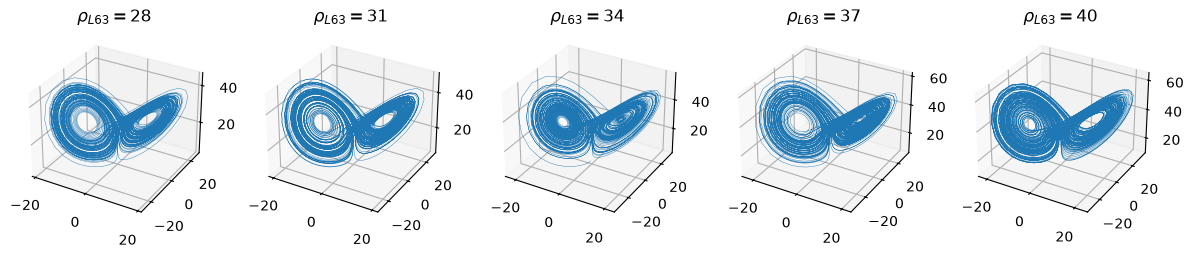

In [2]:
rho_train = np.array([28., 31., 34., 37., 40.])

datasets = [lorenz63_dataset(rho=rho_i, num_lyap_times=100, seed=i)
            for i, rho_i in enumerate(rho_train)]

train_data = np.stack([ds['noisy_data'] for ds in datasets])   # (L, Nt, N_dim)
input_parameters = rho_train[np.newaxis, :]                    # (N_param=1, L)

N_lyap = datasets[0]['N_lyap']
t = datasets[0]['t']
dt = t[1] - t[0]
t_lyap = N_lyap * dt

fig, axs = plt.subplots(1, len(rho_train), figsize=(12, 3),
                        subplot_kw=dict(projection='3d'), layout='tight')
for ax, ds, rho_i in zip(axs, datasets, rho_train):
    ax.plot(*ds['clean_data'].T, lw=0.3)
    ax.set(title=f'$\\rho_{{L63}} = {rho_i:g}$')

# Initialize and train the parametric ESN

Passing `input_parameters` at construction is all it takes: the input dimension
grows by `N_param`, and the parameter normalization is added to the Bayesian
hyperparameter search automatically.

N_dim_in = 4 (3 state dims + 1 parameter)
optimize_parameter_normalization = True



 ----------------- HYPERPARAMETER SEARCH ------------------
 2^4 grid and 14 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 param_shift_0	 param_norm_0	 MSE val 


1	 2.000e-01	 1.000e-02	 1.000e-09	 2.800e+01	 2.000e+00	 -0.8205


2	 2.000e-01	 1.000e-02	 1.000e-10	 2.800e+01	 1.800e+01	 -0.8208


3	 2.000e-01	 1.000e-02	 1.000e-09	 4.000e+01	 2.000e+00	 -0.8218


...

30	 4.486e-01	 1.046e+00	 1.000e-10	 3.000e+01	 1.799e+01	 -1.3851


seed 0 	 Optimal hyperparameters: [0.4537749585991316, 0.05636211992197815, 28.943116724342193, 18.0], 1e-09, MSE: -1.4676170997370526


Running test for L= 0 

1 2 3 

4 Overall tests min, max and mean MSE in 25 tests = -1.632, -1.231, -1.353.


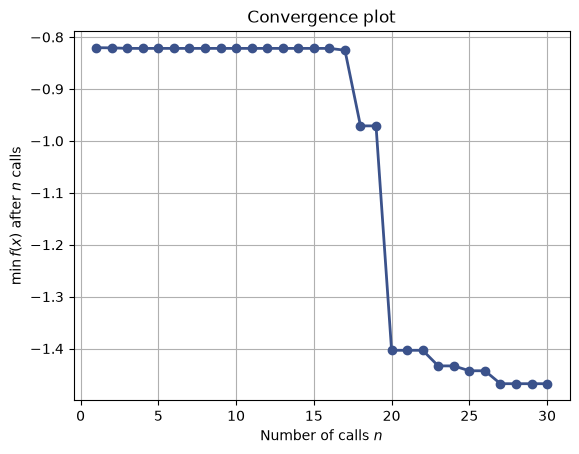

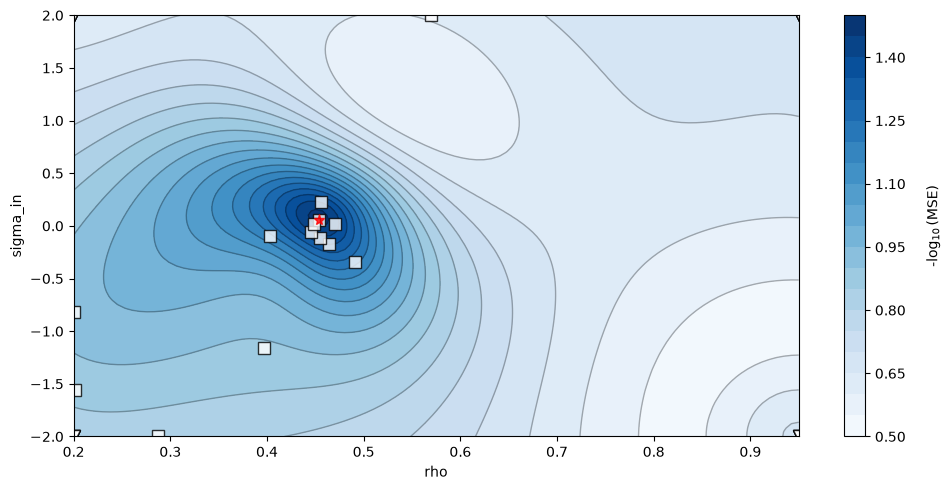

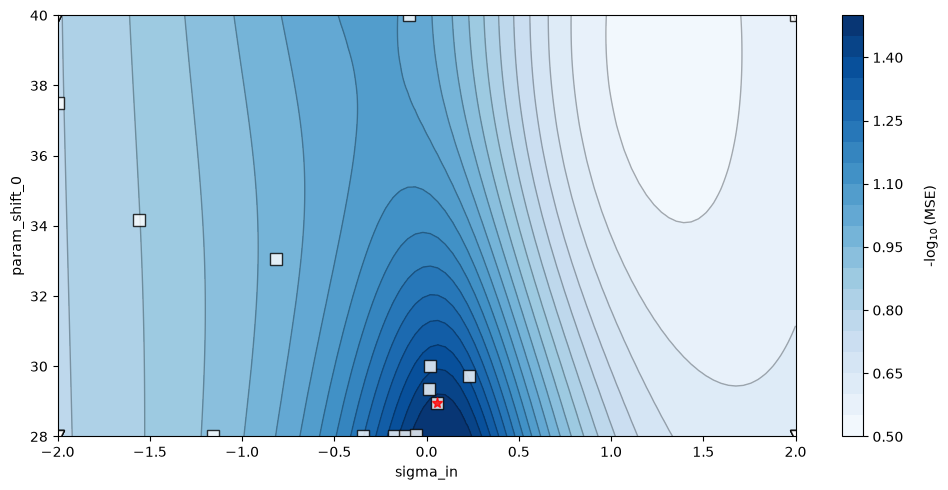

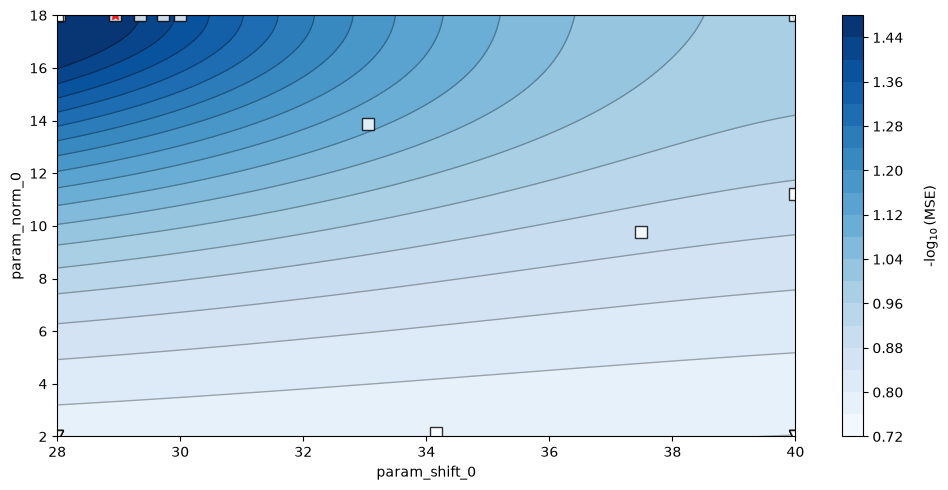

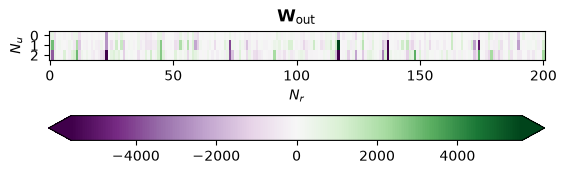

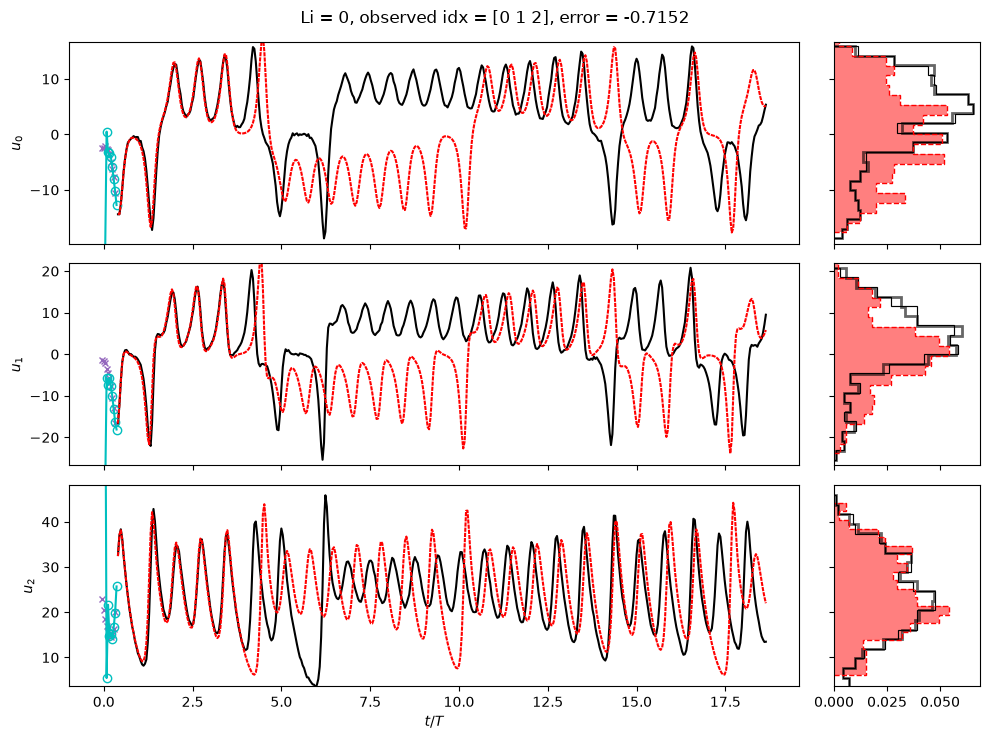

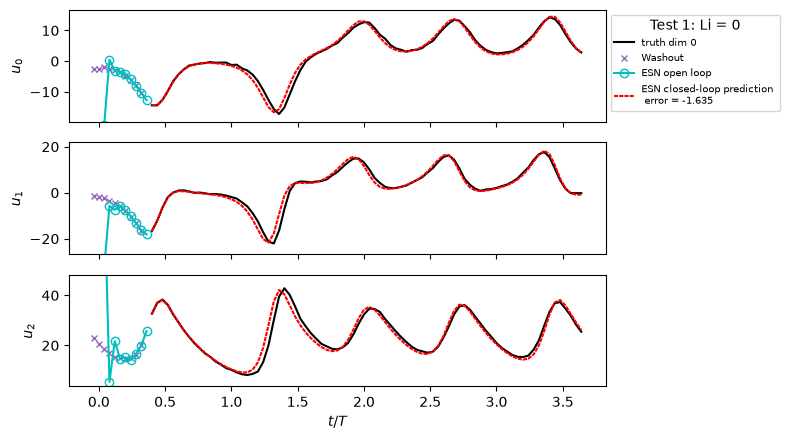

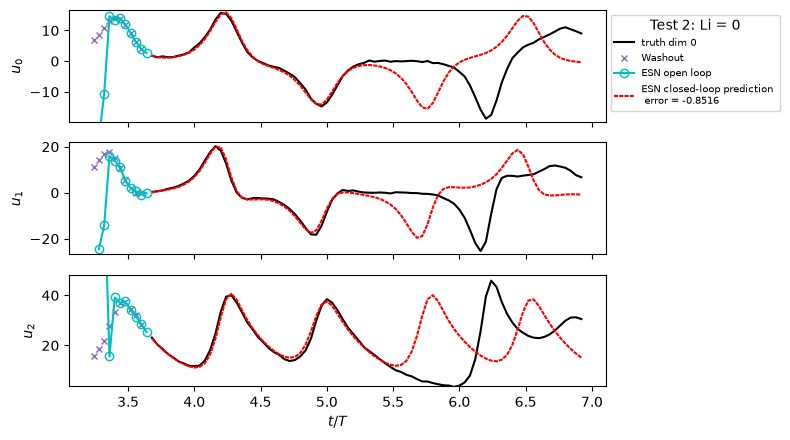

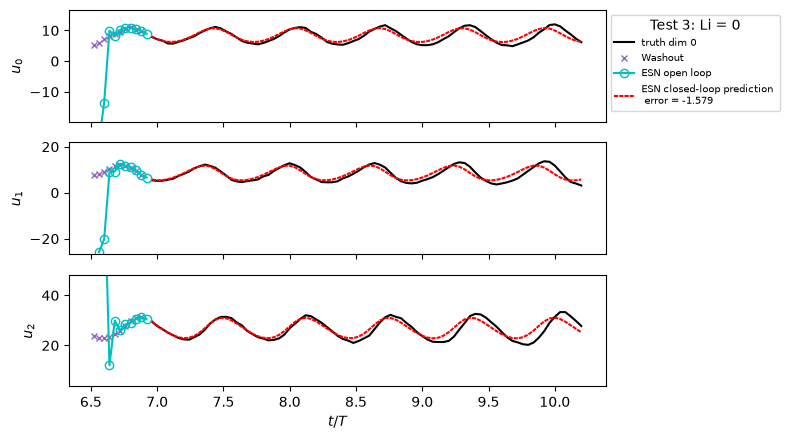

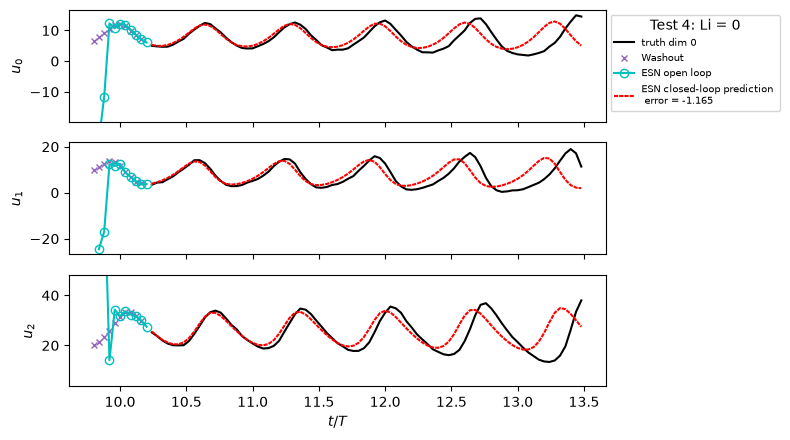

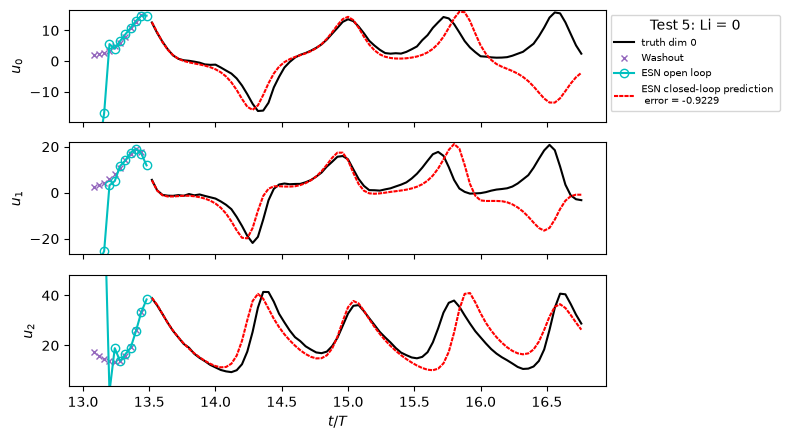

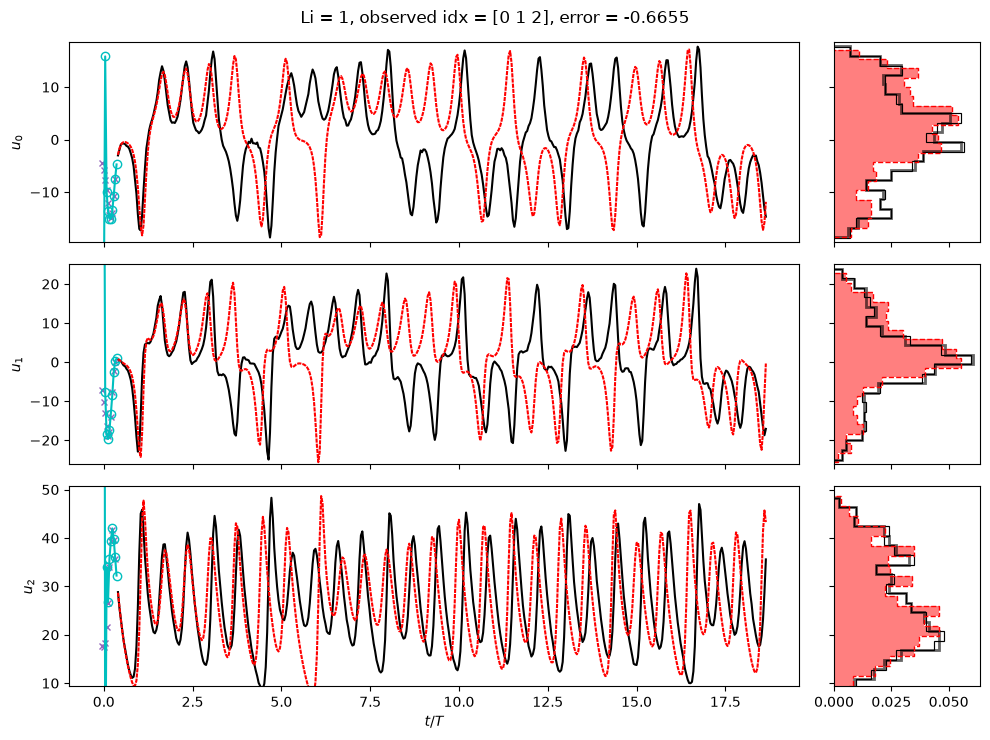

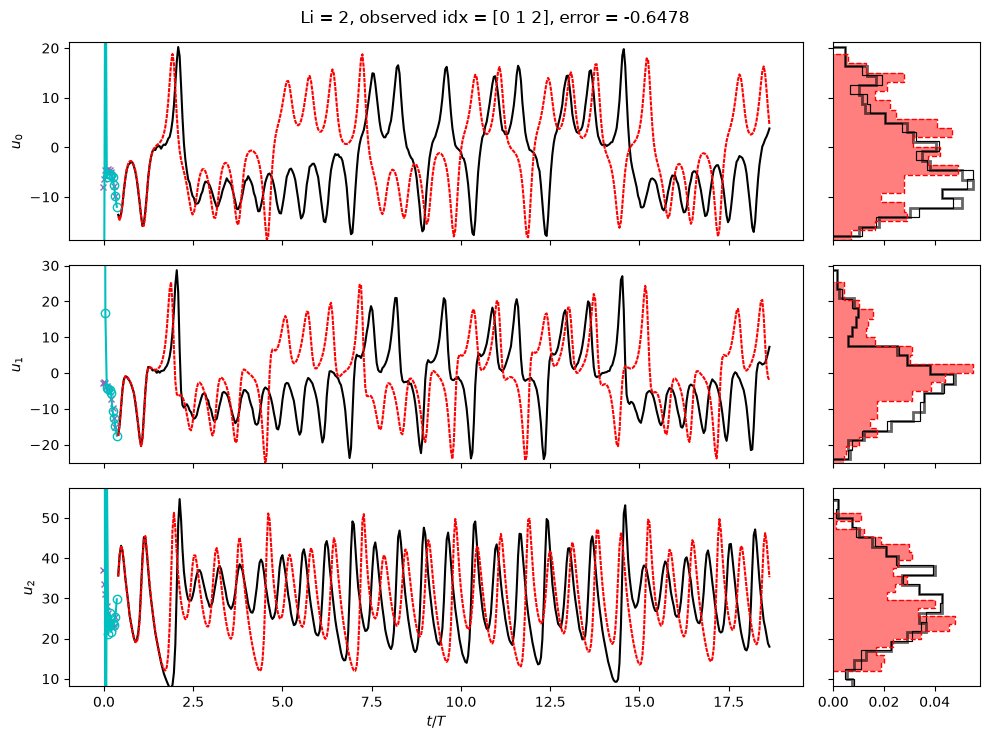

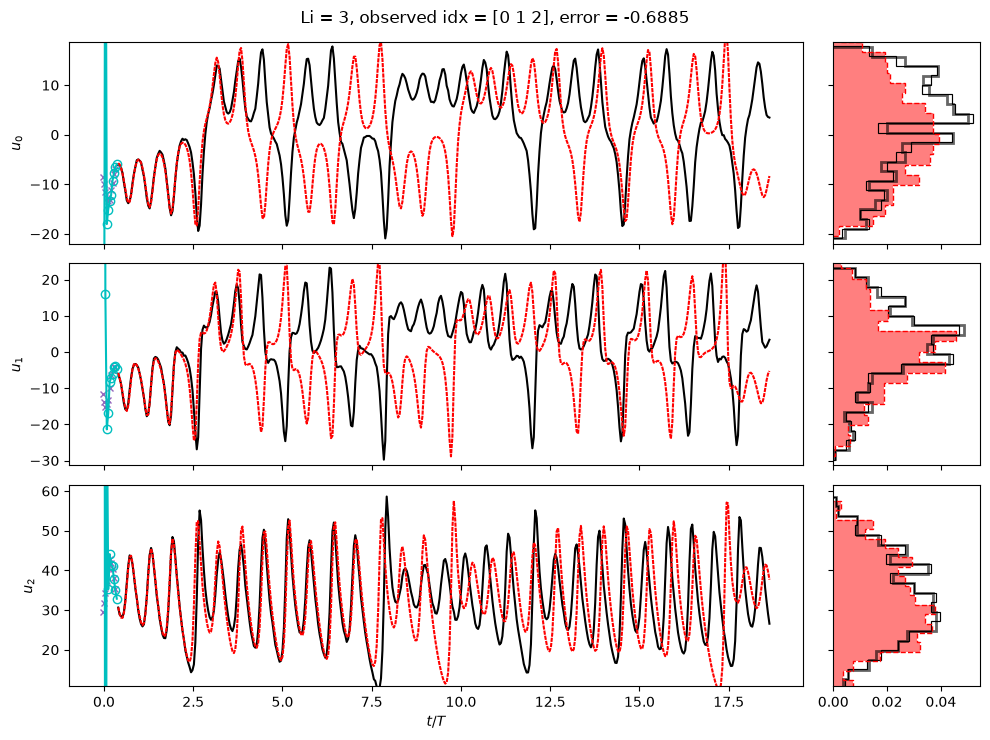

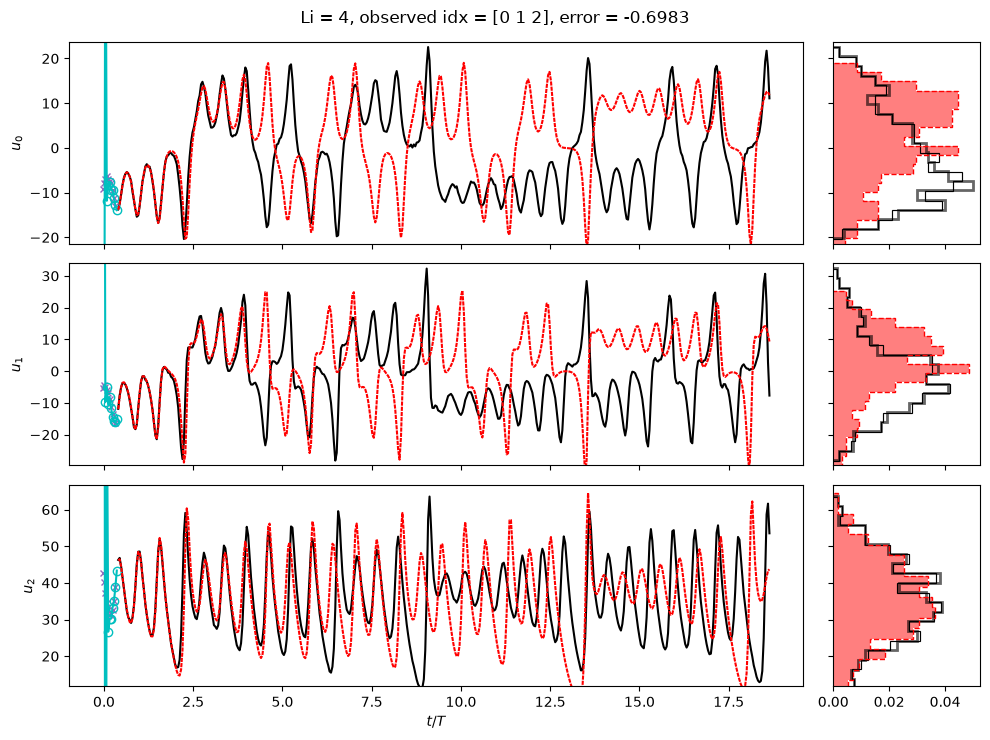

In [3]:
esn = EchoStateNetwork(y=np.zeros((3, 1)),
                       dt=dt,
                       upsample=2,
                       N_wash=10,
                       N_units=200,
                       t_train=80 * t_lyap,
                       t_val=3 * t_lyap,
                       t_test=6 * t_lyap,
                       noise=1e-2,
                       N_folds=6,
                       N_func_evals=30,
                       N_grid=6,
                       rho_range=(.2, .95),
                       sigma_in_range=(-2, 2),
                       tikh_range=[1E-9, 1E-10],
                       input_parameters=input_parameters,
                       )

print(f'N_dim_in = {esn.N_dim_in} (3 state dims + {esn._n_param(input_parameters)} parameter)')
print(f'optimize_parameter_normalization = {esn.optimize_parameter_normalization}')

esn.train(train_data, add_noise=True, plot_training=True)

In [4]:
# The tuned normalization of the parameter column (last entry of shift/norm):
print(f'parameter shift = {esn.shift[-1]:.3g}, norm = {esn.norm[-1]:.3g}')

parameter shift = 28.9, norm = 18


# Forecast at an unseen parameter value

At closed-loop run time `input_parameters` takes shape `(N_param, N_ens)`: the
parameter vector to condition the forecast on, held fixed for the run. We wash
out with a few noisy observations of the target regime, then run the ESN in
closed loop and compare against the clean truth.

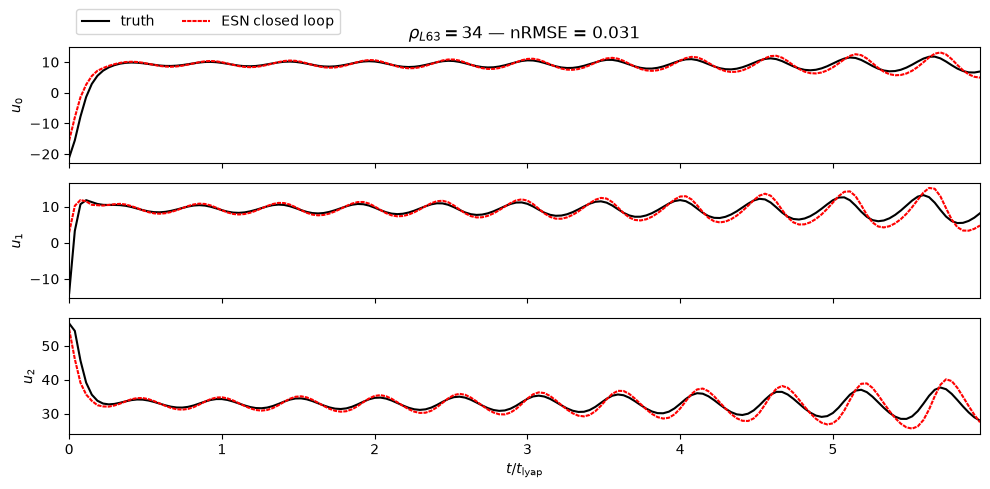

In [5]:
def forecast(esn, rho_test, N_forecast, seed=10):
    """Washout on noisy data at rho_test, then closed-loop forecast."""
    ds = lorenz63_dataset(rho=rho_test, num_lyap_times=15, seed=seed)
    u_in_esn = ds['noisy_data'][::esn.upsample]     # observations at dt_ESN spacing
    truth = ds['clean_data'][::esn.upsample]

    original_input_parameters = esn.input_parameters
    esn.input_parameters = np.array([[rho_test]])   # (N_param, N_ens=1)

    r = np.zeros((esn.N_units, 1))
    for u_i in u_in_esn[:esn.N_wash]:               # open-loop washout
        u_out, r = esn.step(np.concatenate([u_i, [rho_test]]), r)

    Y_pred = np.zeros((N_forecast, esn.N_dim))
    for i in range(N_forecast):                     # closed loop
        u_i = esn.outputs_to_inputs(full_state=u_out)
        u_out, r = esn.step(u_i, r)
        Y_pred[i] = u_out.squeeze()

    esn.input_parameters = original_input_parameters  # restore the (N_param, L) array
    return Y_pred, truth[esn.N_wash:esn.N_wash + N_forecast]


def plot_forecast(esn, rho_test, N_forecast=None):
    N_lyap_esn = int(t_lyap / esn.dt_ESN)           # ESN steps per Lyapunov time
    N_forecast = N_forecast or 6 * N_lyap_esn
    Y_pred, Y_true = forecast(esn, rho_test, N_forecast)
    err = esn.compute_nRMSE(Y_true, Y_pred, norm=np.ptp(Y_true, axis=0))

    t_fc = np.arange(N_forecast) / N_lyap_esn
    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10, 5), layout='tight')
    for dim, ax in enumerate(axs):
        ax.plot(t_fc, Y_true[:, dim], 'k', label='truth')
        ax.plot(t_fc, Y_pred[:, dim], '--r', dashes=[2, .5], label='ESN closed loop')
        ax.set(ylabel=f'$u_{dim}$')
    axs[0].legend(ncols=2, loc='lower left', bbox_to_anchor=(0, 1.05))
    axs[0].set(title=f'$\\rho_{{L63}} = {rho_test:g}$ — nRMSE = {err:.3f}')
    axs[-1].set(xlabel='$t / t_\\mathrm{lyap}$', xlim=(0, t_fc[-1]))


# A parameter value seen in training:
plot_forecast(esn, rho_test=34.)

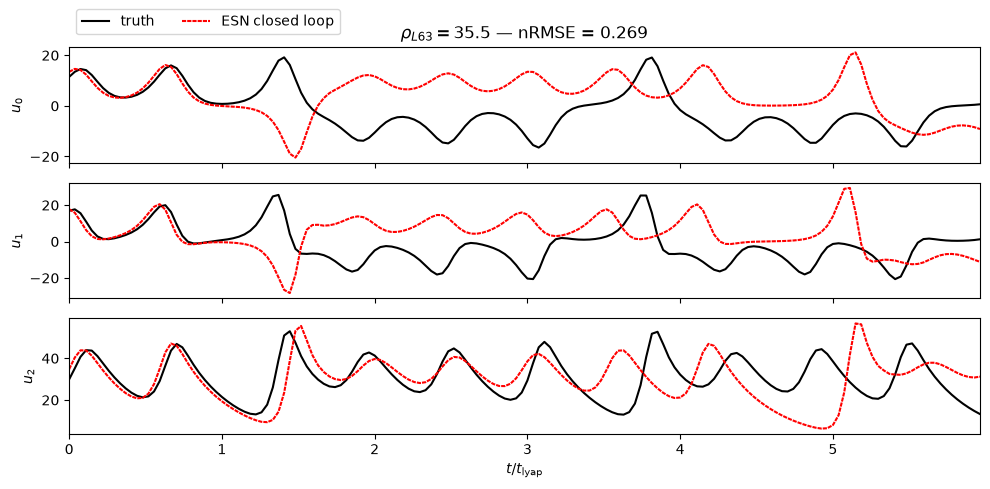

In [6]:
# An unseen parameter value (interpolation within the trained range):
plot_forecast(esn, rho_test=35.5)

The single reservoir tracks the true trajectory for a few Lyapunov times at the
unseen parameter value — the closed-loop forecast is conditioned on
$\rho_{L63}$ purely through the parameter input channel.

Chaotic trajectories diverge; a fairer measure than one run is the ESN's
*statistical* skill (e.g. attractor statistics), which `run_test` reports when
the test window is long enough.